# LAB-D1-02 SOLUTION: The Linear Limit

**INSTRUCTOR ONLY - DO NOT DISTRIBUTE WITH PARTICIPANT MATERIALS**

**Canonical objectives:** `OBJ-D1-04`, `OBJ-D1-05` (reinforces `OBJ-D1-03`)  
**Reference environment:** local CPU; Python 3.11+; no network, download, or GPU  
**Expected compute runtime:** under 20 seconds (reference validation records wall time separately)  
**Execution contract:** Restart Kernel -> Run All; this notebook is standalone.

This solution preserves the participant sequence and completes every prediction, implementation,
diagnosis, reflection, deliberate failure, and practical extension. Labeled instructor answers sit
beside the corresponding prompts. Stored outputs are reference evidence from the clean validation run,
not promises that every supported environment will render identical timings or pixels.


In [1]:
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

SEED = 23
plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True, "grid.alpha": 0.22})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | matplotlib {matplotlib.__version__} | scikit-learn {sklearn.__version__}")
print("Runtime target: local/Colab CPU; no network or GPU required.")

Python 3.11.8 | NumPy 2.4.6 | matplotlib 3.11.1 | scikit-learn 1.9.0
Runtime target: local/Colab CPU; no network or GPU required.


## Observe: Two Classification Patterns

The first generated dataset has two separated clusters. The second contains four noisy, balanced clusters with alternating XOR targets. Point shape and color both encode class so the plots remain interpretable without relying on color alone.

In [2]:
X_blobs, y_blobs = make_blobs(
    n_samples=160, centers=[(-1.5, -1.2), (1.4, 1.3)], cluster_std=0.48, random_state=SEED
)
rng = np.random.default_rng(SEED)
xor_centers = np.array([[-1.0, -1.0], [-1.0, 1.0], [1.0, -1.0], [1.0, 1.0]])
xor_center_labels = np.array([0, 1, 1, 0])
X_xor = np.vstack([rng.normal(center, 0.24, size=(60, 2)) for center in xor_centers])
y_xor = np.repeat(xor_center_labels, 60)

assert X_blobs.shape == (160, 2) and y_blobs.shape == (160,)
assert X_xor.shape == (240, 2) and y_xor.shape == (240,)
assert np.array_equal(np.bincount(y_xor), np.array([120, 120]))
print("Data ready: 160 separable examples and 240 balanced noisy XOR examples.")

Data ready: 160 separable examples and 240 balanced noisy XOR examples.


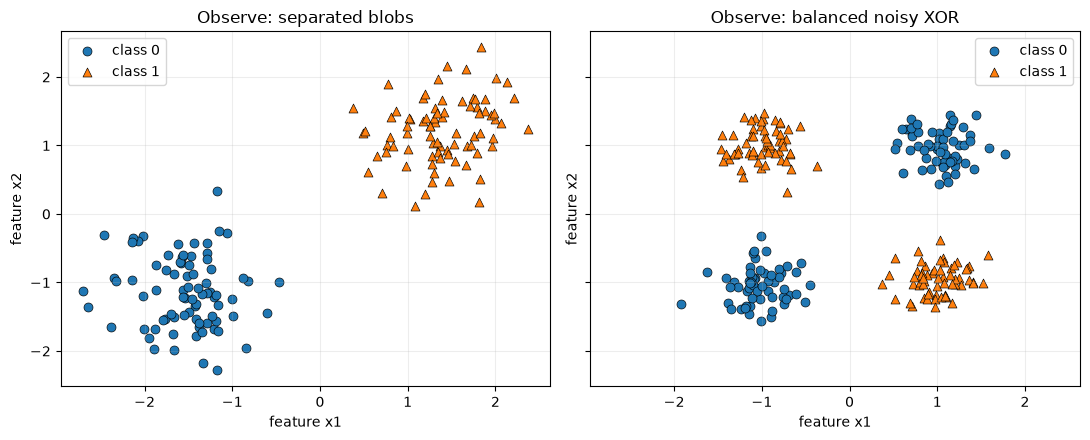

In [3]:
CLASS_STYLES = [(0, "o", "class 0"), (1, "^", "class 1")]


def scatter_classes(ax, X, y, title):
    for label, marker, name in CLASS_STYLES:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], marker=marker, s=42, edgecolor="black", linewidth=0.45, label=name)
    ax.set(xlabel="feature x1", ylabel="feature x2", title=title)
    ax.legend()


def make_mesh(X, padding=0.6, resolution=180):
    x1 = np.linspace(X[:, 0].min() - padding, X[:, 0].max() + padding, resolution)
    x2 = np.linspace(X[:, 1].min() - padding, X[:, 1].max() + padding, resolution)
    xx1, xx2 = np.meshgrid(x1, x2)
    return xx1, xx2, np.column_stack([xx1.ravel(), xx2.ravel()])


def plot_decision_region(ax, X, y, predict_function, title):
    xx1, xx2, grid = make_mesh(X)
    grid_prediction = np.asarray(predict_function(grid)).reshape(xx1.shape)
    ax.contourf(xx1, xx2, grid_prediction, levels=[-0.5, 0.5, 1.5], colors=["#d9e6f2", "#f3ddbd"], alpha=0.65)
    ax.contour(xx1, xx2, grid_prediction, levels=[0.5], colors="black", linewidths=1.8)
    scatter_classes(ax, X, y, title)
    return grid, grid_prediction.ravel()


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
scatter_classes(axes[0], X_blobs, y_blobs, "Observe: separated blobs")
scatter_classes(axes[1], X_xor, y_xor, "Observe: balanced noisy XOR")
plt.tight_layout()
plt.show()

## Predict Before Fitting

Commit to an expected accuracy band and boundary shape for the separated blobs. Then predict an accuracy band and boundary shape for balanced XOR. State whether any expected failure would be caused by representation, parameter choice, optimization time, or another mechanism. Do not fit either model until every field is complete.

In [4]:
linear_predictions = {
    "blobs_accuracy_band": "0.95-1.00 because one line can separate the supplied clusters.",
    "blobs_boundary_shape": "A single straight boundary between the cluster centers.",
    "xor_accuracy_band": "Approximately 0.45-0.60 on balanced noisy XOR.",
    "xor_boundary_shape": "Still one straight line, so alternating corners cannot all be correct.",
    "likely_mechanism": "The XOR failure is representational, not a missing-iteration or code failure.",
}
assert all(value.strip() for value in linear_predictions.values())
for key, value in linear_predictions.items():
    print(f"{key}: {value}")


blobs_accuracy_band: 0.95-1.00 because one line can separate the supplied clusters.
blobs_boundary_shape: A single straight boundary between the cluster centers.
xor_accuracy_band: Approximately 0.45-0.60 on balanced noisy XOR.
xor_boundary_shape: Still one straight line, so alternating corners cannot all be correct.
likely_mechanism: The XOR failure is representational, not a missing-iteration or code failure.


### Instructor Answer and Hint Ladder

**Prediction:** Blobs should be near perfect with one line; balanced XOR should remain near chance
because its alternating corners are not linearly separable.

**Hints before reveal:** (1) Draw one line. (2) Name the two corners on each side. (3) Ask whether more
optimizer steps change the boundary family. Do not reveal the fixed nonlinear parameters yet.

**Common wrong answer:** "Sigmoid bends the decision boundary." At threshold `0.5`, sigmoid maps back
to affine score `z=0`, which is still a line.


## Modify: Fit and Measure One Linear Classifier

Complete the two focused TODOs. Use `LogisticRegression(C=1.0, solver="lbfgs", max_iter=max_iter)` so both datasets use the same explicit estimator settings. `classification_accuracy` should return a scalar fraction, not a percentage string.

In [5]:
def fit_logistic(X, y, max_iter=1000):
    model = LogisticRegression(C=1.0, solver="lbfgs", max_iter=max_iter)
    return model.fit(X, y)


def classification_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Target/prediction shapes differ: {y_true.shape} vs {y_pred.shape}")
    return float(np.mean(y_true == y_pred))


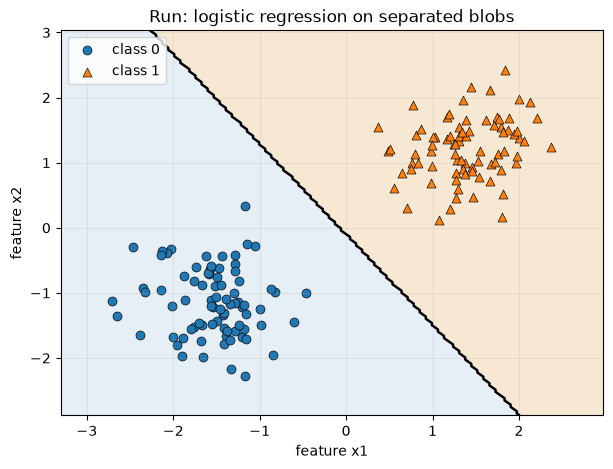

Separated-blobs accuracy: 1.000


In [6]:
blob_model = fit_logistic(X_blobs, y_blobs)
blob_predictions = blob_model.predict(X_blobs)
blob_accuracy = classification_accuracy(y_blobs, blob_predictions)
fig, ax = plt.subplots(figsize=(7, 5))
blob_mesh, blob_mesh_predictions = plot_decision_region(ax, X_blobs, y_blobs, blob_model.predict, "Run: logistic regression on separated blobs")
plt.show()
assert np.array_equal(blob_mesh_predictions, blob_model.predict(blob_mesh))
print(f"Separated-blobs accuracy: {blob_accuracy:.3f}")
assert 0.95 <= blob_accuracy <= 1.00, "Check the supplied data and estimator settings."

### Instructor Reference Result

**Expected deterministic value:** blob accuracy `1.0000` under the validated environment.  
**What happened?** One line separated the two clusters.  
**Why?** The data geometry fits the model family.  
**Concept:** Establish a credible success control before diagnosing a limitation.


## Predict Again: XOR and More Iterations

Now that the success case is visible, revisit only your XOR prediction. Will a much larger iteration budget change the family of possible boundaries, or only give the optimizer more opportunity to place a member of the same family? Record one visual observation that could distinguish those explanations.

In [7]:
xor_recommitment = {
    "more_iterations": "More iterations can refine placement but cannot turn one affine threshold into multiple XOR regions.",
    "discriminating_visual": "Compare both decision-region plots; if both remain one line, the representational family did not change.",
}
assert all(value.strip() for value in xor_recommitment.values())


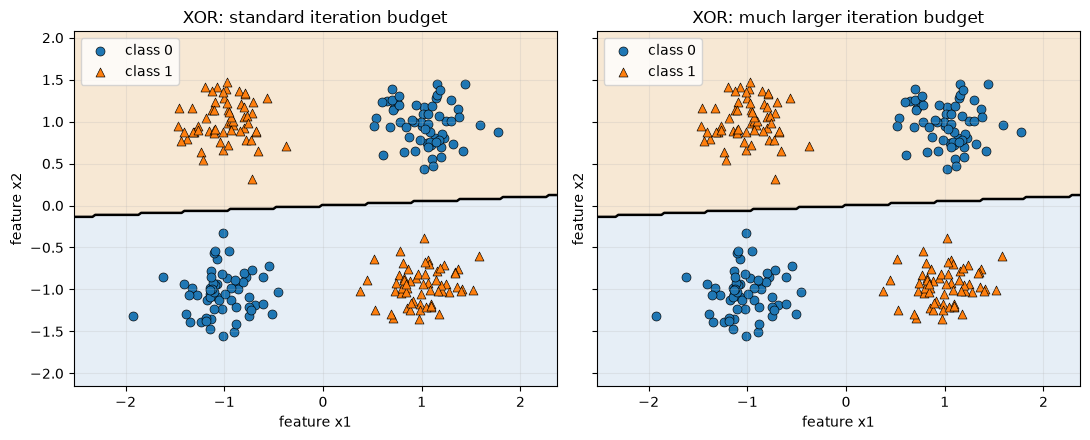

XOR accuracy: standard=0.500, larger-budget=0.500


In [8]:
xor_model = fit_logistic(X_xor, y_xor, max_iter=1000)
xor_long_model = fit_logistic(X_xor, y_xor, max_iter=10000)
xor_predictions = xor_model.predict(X_xor)
xor_long_predictions = xor_long_model.predict(X_xor)
xor_accuracy = classification_accuracy(y_xor, xor_predictions)
xor_long_accuracy = classification_accuracy(y_xor, xor_long_predictions)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
plot_decision_region(axes[0], X_xor, y_xor, xor_model.predict, "XOR: standard iteration budget")
plot_decision_region(axes[1], X_xor, y_xor, xor_long_model.predict, "XOR: much larger iteration budget")
plt.tight_layout()
plt.show()
print(f"XOR accuracy: standard={xor_accuracy:.3f}, larger-budget={xor_long_accuracy:.3f}")
assert 0.45 <= xor_accuracy <= 0.60 and 0.45 <= xor_long_accuracy <= 0.60

### Instructor Reference Result

**Expected deterministic values:** standard iterations `0.5000`; larger budget `0.5000`.

**What happened?** Training longer left performance at chance and both boundaries linear.  
**Why?** Iterations search within the same affine family.  
**Concept:** Representation failure differs from optimization time or implementation failure.


## Diagnose the Linear Failure

Identify at least two XOR regions that cannot both be placed correctly by the displayed line. Explain why the successful blob result matters to this diagnosis. Distinguish a representation limit from an implementation error and from an optimizer that stopped too early.

In [9]:
linear_diagnosis = {
    "inseparable_regions": "The low-low and high-high class-0 corners alternate with low-high and high-low class-1 corners, so any line puts at least one required region on the wrong side.",
    "success_case_value": "The 1.000 blob result shows the estimator and plotting path can work when the geometry is linearly separable.",
    "failure_type": "This is a raw-space representation limit, not a crash and not evidence of early optimizer stopping.",
}
assert all(value.strip() for value in linear_diagnosis.values())


## Predict: Fixed Two-Unit Hidden Transformation

The next model is not trained here. It uses a supplied `2 -> 2 -> 1` parameter set. Predict what will happen on clean XOR corners and noisy XOR when the hidden activation is ReLU. Then predict what will happen when the activation is replaced by identity while every parameter and data point stays fixed.

Commit to whether adding layer-shaped matrix operations alone is sufficient, or whether the nonlinear transformation is the discriminating change.

In [10]:
hidden_predictions = {
    "relu_clean_corners": "All four clean corners should be correct (1.00).",
    "relu_noisy_xor": "The supplied separated clusters should typically exceed 0.90 accuracy.",
    "identity_same_parameters": "The composed map is affine again and should return to roughly chance.",
    "discriminating_change": "Only the hidden activation changes; data and every parameter remain identical.",
}
assert all(value.strip() for value in hidden_predictions.values())


In [11]:
fixed_parameters = {
    "W1": np.array([[1.0, -1.0], [1.0, -1.0]]),
    "b1": np.array([-0.5, -0.5]),
    "W2": np.array([[-4.0], [-4.0]]),
    "b2": np.array([2.0]),
}
fixed_snapshot = {name: value.copy() for name, value in fixed_parameters.items()}
clean_XOR = xor_centers.copy()
clean_XOR_targets = xor_center_labels.copy()
print({name: value.shape for name, value in fixed_parameters.items()})

{'W1': (2, 2), 'b1': (2,), 'W2': (2, 1), 'b2': (1,)}


## Modify: Implement the Fixed Forward Function

Complete the focused TODOs. `two_unit_forward` must return hidden pre-activations `(n, 2)`, hidden activations `(n, 2)`, and probabilities `(n, 1)`. The `hidden_activation` argument lets the same parameter set run with ReLU or identity.

In [12]:
def relu(values):
    return np.maximum(0.0, np.asarray(values, dtype=float))


def stable_sigmoid(values):
    values = np.asarray(values, dtype=float)
    result = np.empty_like(values)
    nonnegative = values >= 0
    result[nonnegative] = 1.0 / (1.0 + np.exp(-values[nonnegative]))
    exp_values = np.exp(values[~nonnegative])
    result[~nonnegative] = exp_values / (1.0 + exp_values)
    return result


def two_unit_forward(X, parameters, hidden_activation):
    X = np.asarray(X, dtype=float)
    Z1 = X @ parameters["W1"] + parameters["b1"]
    H = hidden_activation(Z1)
    Z2 = H @ parameters["W2"] + parameters["b2"]
    probability = stable_sigmoid(Z2)
    return Z1, H, probability


def network_classes(probabilities, threshold=0.5):
    probabilities = np.asarray(probabilities)
    if probabilities.ndim != 2 or probabilities.shape[1] != 1:
        raise ValueError(f"Expected probabilities (n, 1); got {probabilities.shape}")
    return (probabilities[:, 0] >= float(threshold)).astype(int)


In [13]:
identity = lambda values: values
clean_Z1, clean_hidden, clean_probability = two_unit_forward(clean_XOR, fixed_parameters, relu)
xor_Z1, xor_hidden, xor_probability = two_unit_forward(X_xor, fixed_parameters, relu)
identity_Z1, identity_hidden, identity_probability = two_unit_forward(X_xor, fixed_parameters, identity)
clean_network_accuracy = classification_accuracy(clean_XOR_targets, network_classes(clean_probability))
nonlinear_xor_accuracy = classification_accuracy(y_xor, network_classes(xor_probability))
identity_xor_accuracy = classification_accuracy(y_xor, network_classes(identity_probability))

assert clean_hidden.shape == (4, 2) and clean_probability.shape == (4, 1)
assert xor_hidden.shape == (240, 2) and xor_probability.shape == (240, 1)
assert np.all((xor_probability >= 0.0) & (xor_probability <= 1.0))
print(f"Fixed nonlinear network: clean={clean_network_accuracy:.3f}, noisy={nonlinear_xor_accuracy:.3f}")
print(f"Same parameters with identity activation: noisy={identity_xor_accuracy:.3f}")

Fixed nonlinear network: clean=1.000, noisy=1.000
Same parameters with identity activation: noisy=0.500


### Instructor Reference Result and Debrief

**Expected deterministic values:** ReLU clean corners `1.0000`; noisy XOR `1.0000`; identity control
`0.5000`.

**What happened?** The ReLU path classified alternating regions, while the same matrices with identity
returned to chance.  
**Why?** ReLU changes the coordinates piecewise; identity lets the two affine layers algebraically
collapse into one affine map.  
**Concept:** Extra layer shapes are insufficient; nonlinear composition changes representational power.

**Interpretation limit:** This fixed network was not trained in the lab. It demonstrates a possible
forward representation, not how parameters were learned.


## Visualize: Linked Raw and Hidden Coordinates

The same point shapes, class colors, and clean-corner labels appear in both panels. Track point identity rather than treating the hidden plot as a new dataset. The hidden output boundary remains a straight cut; inspect what changed about the coordinates it receives.

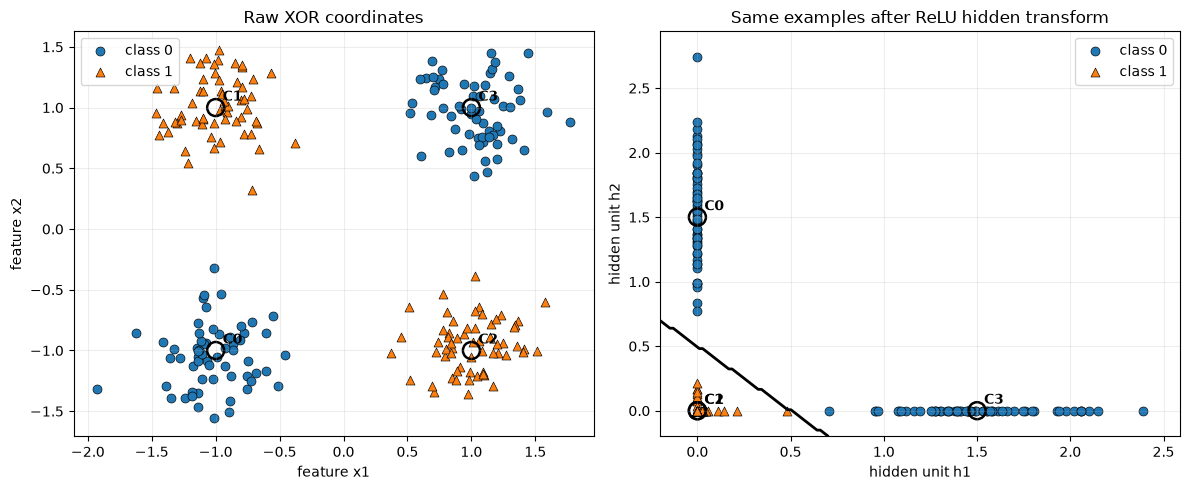

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter_classes(axes[0], X_xor, y_xor, "Raw XOR coordinates")
for index, point in enumerate(clean_XOR):
    axes[0].annotate(f"C{index}", point, xytext=(5, 5), textcoords="offset points", weight="bold")
    axes[0].scatter(*point, s=150, facecolors="none", edgecolors="black", linewidths=1.8)

scatter_classes(axes[1], xor_hidden, y_xor, "Same examples after ReLU hidden transform")
for index, point in enumerate(clean_hidden):
    axes[1].annotate(f"C{index}", point, xytext=(5, 5), textcoords="offset points", weight="bold")
    axes[1].scatter(*point, s=150, facecolors="none", edgecolors="black", linewidths=1.8)
hidden_x1 = np.linspace(xor_hidden[:, 0].min() - 0.2, xor_hidden[:, 0].max() + 0.2, 160)
hidden_x2 = np.linspace(xor_hidden[:, 1].min() - 0.2, xor_hidden[:, 1].max() + 0.2, 160)
hh1, hh2 = np.meshgrid(hidden_x1, hidden_x2)
hidden_grid = np.column_stack([hh1.ravel(), hh2.ravel()])
hidden_grid_class = network_classes(stable_sigmoid(hidden_grid @ fixed_parameters['W2'] + fixed_parameters['b2'])).reshape(hh1.shape)
axes[1].contour(hh1, hh2, hidden_grid_class, levels=[0.5], colors="black", linewidths=2)
axes[1].set(xlabel="hidden unit h1", ylabel="hidden unit h2")
plt.tight_layout()
plt.show()

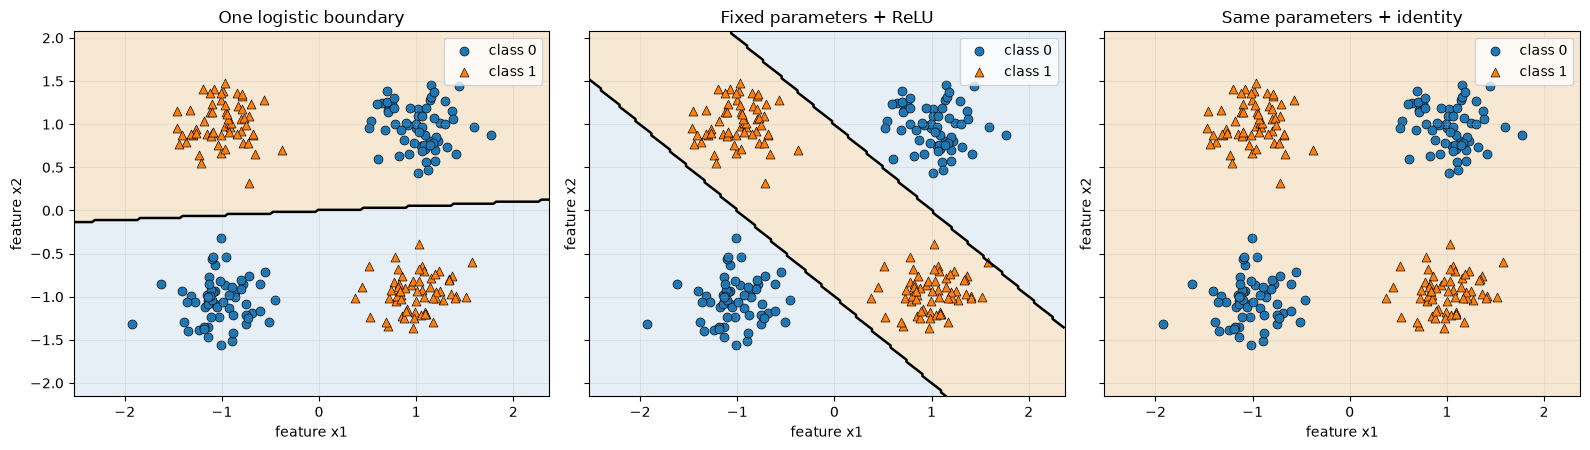

In [15]:
def fixed_predict(X, activation):
    return network_classes(two_unit_forward(X, fixed_parameters, activation)[2])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True)
plot_decision_region(axes[0], X_xor, y_xor, xor_model.predict, "One logistic boundary")
plot_decision_region(axes[1], X_xor, y_xor, lambda X: fixed_predict(X, relu), "Fixed parameters + ReLU")
plot_decision_region(axes[2], X_xor, y_xor, lambda X: fixed_predict(X, identity), "Same parameters + identity")
plt.tight_layout()
plt.show()

## Diagnose and Explain

Use the linked plots and three-region comparison to answer:

1. Why was the blob success an important baseline?
2. What evidence makes XOR a representation failure for one linear boundary?
3. Did the output boundary become complicated, or did the hidden coordinates change?
4. Why did identity activation collapse the layered computation back to a linear family?
5. What evidence would distinguish useful nonlinearity from merely adding parameters?

In [16]:
explanation = {
    "baseline_value": "The blob model reached 1.000, confirming that the estimator and one-line family are useful when aligned with the data.",
    "representation_evidence": "Both 1,000- and 10,000-iteration XOR runs stayed at 0.500 with one straight boundary across alternating regions.",
    "hidden_coordinate_change": "The ReLU hidden coordinates regroup the same point identities so a straight output cut becomes useful; the output boundary is not curved in hidden space.",
    "identity_collapse": "With identity, XW1+b1 followed by W2,b2 equals X(W1W2)+(b1W2+b2), another affine map.",
    "discriminating_evidence": "Hold data and parameters fixed, change only ReLU to identity, and compare region shape and accuracy.",
}
assert all(value.strip() for value in explanation.values())
assert 0.95 <= blob_accuracy <= 1.00
assert 0.45 <= xor_accuracy <= 0.60
assert clean_network_accuracy == 1.0
assert nonlinear_xor_accuracy > 0.90
assert 0.45 <= identity_xor_accuracy <= 0.60
assert all(np.array_equal(fixed_parameters[name], fixed_snapshot[name]) for name in fixed_parameters)
print("LAB-D1-02 checkpoint passed: success case, linear failure, nonlinear transform, identity control, and parameter parity.")


LAB-D1-02 checkpoint passed: success case, linear failure, nonlinear transform, identity control, and parameter parity.


## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| Prediction cell stops | A response is empty | Commit a prediction before revealing model evidence |
| Logistic estimator does not fit | The TODO returns an unfitted object or uses incompatible shapes | Fit on `(n, 2)` data and `(n,)` targets, then return the estimator |
| XOR score is unexpectedly high | Data or labels changed, or balance was lost | Restart and rerun the supplied seeded generator unchanged |
| Network matrix error | `W1`, `b1`, `W2`, or `b2` orientation changed | Compare against `(2,2)`, `(2,)`, `(2,1)`, `(1,)` |
| Identity and ReLU use different results | Parameters or data were mutated | Restart; both comparisons must call the same forward function with one activation change |
| Hidden plot seems unrelated | Point identity was not tracked | Follow matching class markers and clean-corner labels across panels |

## Optional Extension: Shift the Hidden Hinges

Change only `b1` in a copied dictionary, preserving data and all other parameters. Predict that ReLU
hinge locations and therefore hidden coordinates/decision regions may move.


In [17]:
shifted_parameters = {name: value.copy() for name, value in fixed_parameters.items()}
shifted_parameters["b1"] = shifted_parameters["b1"] + np.array([0.25, -0.25])
shifted_probability = two_unit_forward(X_xor, shifted_parameters, relu)[2]
shifted_accuracy = classification_accuracy(y_xor, network_classes(shifted_probability))
assert all(np.array_equal(fixed_parameters[name], fixed_snapshot[name]) for name in fixed_parameters)
print(f"Copied-b1 extension accuracy: baseline={nonlinear_xor_accuracy:.3f}, shifted={shifted_accuracy:.3f}")
print("Mean absolute probability shift:", float(np.mean(np.abs(shifted_probability - xor_probability))))


Copied-b1 extension accuracy: baseline=1.000, shifted=0.996
Mean absolute probability shift: 0.033267342184867134


### Instructor Extension Answer

**What happened?** The copied offsets changed hidden values and probabilities; the exact aggregate
accuracy may remain high because many points stay far from the boundary.  
**Why?** `b1` translates the two hidden pre-activation thresholds before ReLU.  
**Concept:** Parameters and activation hinges jointly determine the representation; unchanged accuracy
does not imply unchanged computation.

Accept other bounded copied offsets when the canonical arrays remain immutable and the learner compares
hidden/probability evidence rather than demanding a score change.

## Takeaways

- A linear success control makes the XOR diagnosis credible.
- More iterations cannot change a one-line representational family.
- ReLU changes hidden coordinates; identity collapses to an affine map.
- Accuracy and linked raw/hidden plots provide complementary evidence.


## Instructor Operations and Recovery

**Dependency/import issues:** Confirm the selected kernel contains NumPy and matplotlib; Labs 2 and 4
also require scikit-learn. Run the version cell first after any install, restart the kernel, and rerun
from the top. Day 1 uses no network data.

**Shape/order issues:** Print operand shapes at the failing matrix multiplication and compare them with
the batch-first contract. A passing shape is not enough for softmax or threshold semantics, so rerun the
stated invariant too. Never continue after running cells out of order; restart and Run All.

**Unexpected metrics/random differences:** Restore the canonical seed, supplied data, explicit estimator
settings, and fixed parameter arrays. Treat documented metric bands as checks and deterministic reference
values as evidence for this exact setup. Do not tune around a changed environment during a live class.

**Plotting/runtime/memory:** If plots do not display, restart the backend/kernel and rerun imports. If a
live render is slow, use the stored output and keep the prediction/debrief. These notebooks use small
arrays and are CPU practical; GPU changes neither the required evidence nor the explanation.

**Colab:** Select a CPU runtime. Package pins are documented in `courseware/shared/environment.md`, but a
hosted Colab run remains a separate validation claim. Do not describe local execution as Colab validation.


    **Lab-specific stuck points:** If a learner says the output line bent, trace clean-corner identities into
    hidden space and point to the straight hidden threshold. If metrics drift, restore seed `23`, noise
    `0.24`, explicit `LogisticRegression` settings, and the canonical parameter arrays. Alternative valid
    nonlinear weights are acceptable only as extensions; the core same-parameter ReLU/identity control
    must stay unchanged.
